## STOCHASTIC MODELING
MODULE 1 | LESSON 1


---


# **STOCHASTIC VOLATILITY: HESTON**


|  |  |
|:---|:---|
|**Reading Time** |  1 hour |
|**Prior Knowledge** | Black-Scholes, Local-volatility |
|**Keywords** |Stochastic volatility, Heston model, Skewness, Kurtosis |


---

During the previous Derivative Pricing course we learnt the basics of option pricing in discrete and continuous time. We explored the most famous (and revolutionary, at its time) pricing model, the **Black-Scholes** model (BS), only to  discover that some of its assumptions are pretty hard to reconcile with empirical observations.

One important  dimension in which BS falls short is the constant volatility  assumption. In the last  module of  Derivative  Pricing we made some progress in relaxing this assumption by considering Local Volatility  models. They helped in terms of replicating the *volatility smile (or smirk)*, but they were not enough. Now, its time to get familiar with more complex models that consider **stochastic volatilty**

## **1. The Heston Model**


The Heston model comprises, essentially, two SDEs: one for the asset (Eq. 1) and one for its variance (Eq. 2):

\begin{equation}
    dS = \mu S dt + \sqrt{\nu(t)}S dZ_1
\end{equation}

\begin{equation}
    d\nu(t) = \kappa \left( \theta - \nu(t) \right) dt + \sigma \sqrt{\nu(t)}dZ_2
\end{equation}

where $dZ_1$ and $dZ_2$ are Wiener processes with correlation $\rho$.


- In Equation 1 (**SDE for asset**), under a risk-neutral setting, we'll have $\mu = r$.

- Equation 2 (**SDE for variance**) is what is new to us (is it though? $\rightarrow$ remember Vasicek and its parameters?)

  $\theta$, long run average variance.
        
  $\kappa$, rate of mean-reversion.
        
  $\sigma$, volatility of volatility (vol of vol).

In [2]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1116720055", h="3298dbabb7", width=700, height=450)


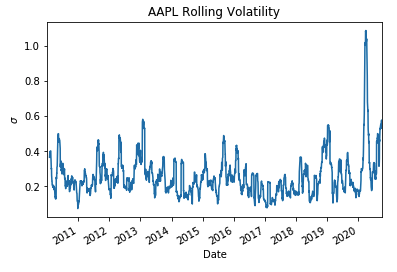

## **2. Simulating the Heston Model in Python**

As we have just seen, we can simulate stock price paths under Heston model dynamics with the following two equations:
$$
\begin{equation*}
    S_t = S_{t-1} e^{\left( r - \frac{\nu_t}{2} \right) dt +  \sqrt{\nu_t} dZ_1}
\end{equation*}
$$
$$
\begin{equation*}
    \nu_t = \nu_{t-1} + \kappa \left( \theta - \nu_{t-1} \right) dt + \sigma \sqrt{\nu_{t-1}}dZ_2
\end{equation*}
$$
\
Importantly, these equations require some parameters, whose functional form is currently unknown to us. At this step, we will just give some values to these parameters to generate sample paths. In the next lesson, we will look at some semi-analytical ways (e.g., Fourier transform methods) to obtain a functional form for these.

We will start by coding the **stochastic volatility function**, $\nu_t$:

*Notice how we calculate $\nu_t$ as the maximum between the $\nu_t$ expression above and 0. This is to ensure that we do not get a negative number here because of the random process. Obviously, it does not make any sense whatsoever to have negative variance!*

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

In [30]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

Next, let's implement the classic **stochastic equation** for the underlying asset price evolution:

In [29]:
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

The last function we will define, just for simplifying the tasks, will be a **random number generator** following a standard normal:

In [19]:
def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

Now that we have defined the main functions to use in the process, let's implement the Heston model under some parameters (assume these are given for now):

In [20]:
v0 = 0.04
kappa_v = 2
sigma_v = 0.3
theta_v = 0.04
rho = -0.9

S0 = 100  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 1  # Number of years
M = int(M0*T) # Total time steps
I = 10000  # Nomber of simulations
dt = T/M  # Length of time step

Finally, let's work on the random number generator and the covariance matrix (using Cholesky decomposition to account for correlation between $dZ_1$ and $dZ_2$):

In [21]:
# Generating random numbers from standard normal
rand = random_number_gen(M, I)


# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

Now we have all the ingredients to generate the paths for both asset price and its volatility:

In [22]:
# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
S = Heston_paths(S0, r, V, 0, cho_matrix)

Let's visualize some of the paths for both the underlying price and the volatility:

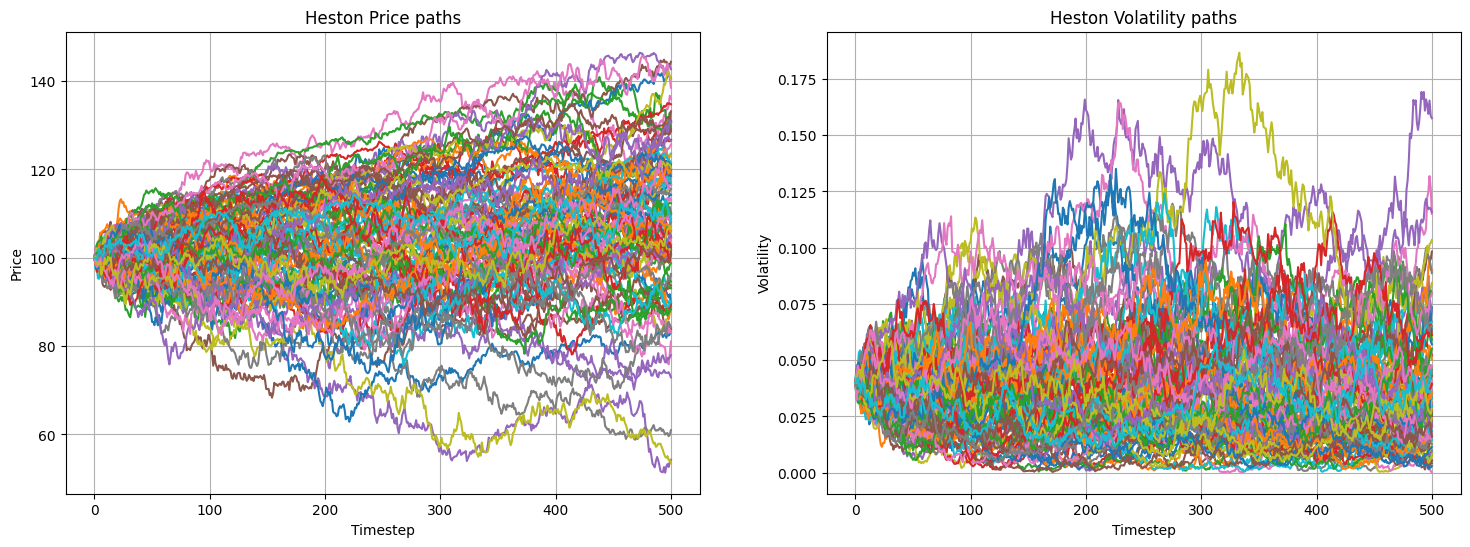

In [10]:
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(100)

## 🔧 Code Task 1.1: Simulate Heston Model with New Parameters

In this task, you'll simulate new paths for both volatility and underlying price using the **Heston stochastic volatility model**.

Your tasks:

1. Set the correlation parameter to:
   - `rho_new = -0.5`

2. Update the mean-reversion speed:
   - `kappa_v_new = 1.5`

3. Reduce the number of simulations:
   - `I_new = 100` (only simulate 100 paths)

4. Simulate the **volatility paths** using the provided `SDE_vol()` function and store them in `V_new`.

5. Simulate the **price paths** using the provided `Heston_paths()` function and store them in `S_new`.

6. Use the `plot_paths(100)` function to visualize the first 100 simulated paths for both volatility and price.

Make sure to:

- Use the provided skeleton code for continuity
- Define any missing variables before using them
- Reuse the function names and structure to match the assessment checks


In [34]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M
    v = np.zeros((M + 1, I))
    v[0] = v0
    sdt = np.sqrt(dt)

    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])  # (2, I)
        v[t] = np.maximum(
            0,
            v[t - 1]
            + kappa * (theta - v[t - 1]) * dt
            + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt
        )
    return v

In [39]:
def Heston_paths(S0, r, v, row, cho_matrix, rand, dt, M, I):
    S = np.zeros((M+1, I))
    S[0] = S0
    sdt = np.sqrt(dt)

    for t in range(1, M+1):
        ran = np.dot(cho_matrix, rand[:, t])  # (2, I)
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * v[t-1]) * dt
            + np.sqrt(v[t-1]) * ran[row] * sdt
        )
    return S

[[0.04       0.04       0.04       ... 0.04       0.04       0.04      ]
 [0.03578891 0.03862416 0.03844038 ... 0.04230357 0.04133905 0.03948945]
 [0.0408625  0.03918062 0.04338587 ... 0.03877339 0.04436836 0.04288615]
 ...
 [0.00206144 0.06182024 0.03257118 ... 0.15132705 0.03098012 0.0078005 ]
 [0.00244767 0.06045499 0.03317826 ... 0.15731082 0.0297736  0.00908593]
 [0.0033322  0.05900676 0.03426845 ... 0.15263588 0.03042311 0.01082571]]


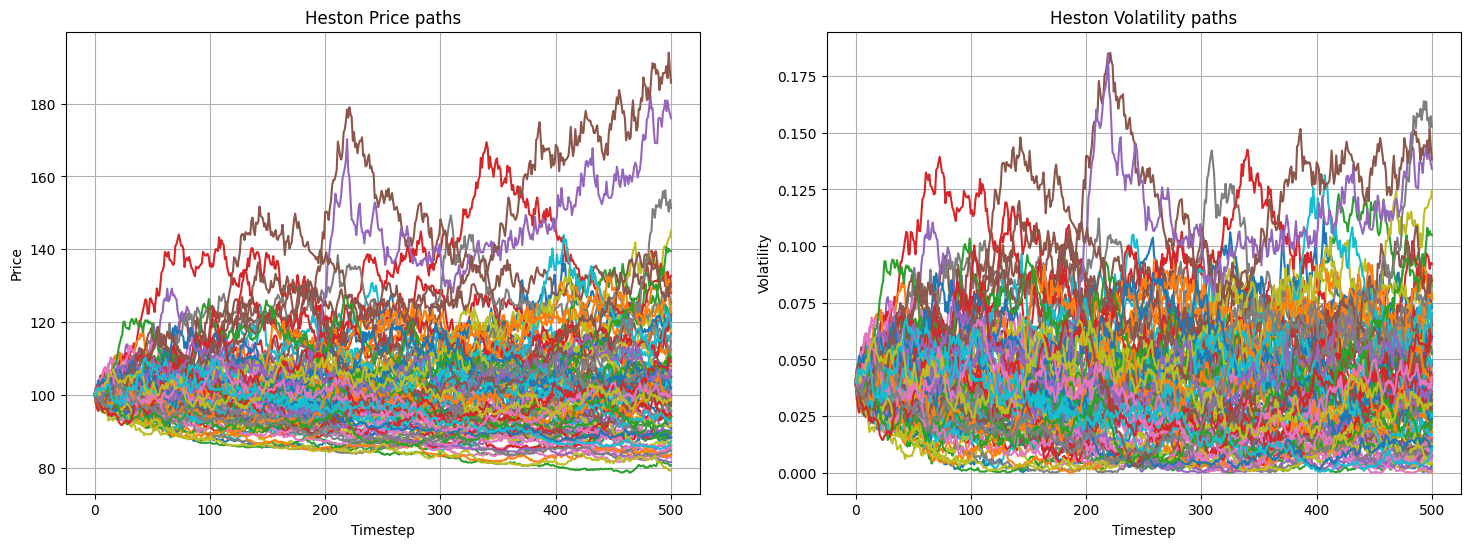

In [42]:
v0 = 0.04
kappa_v_new = 1.5
sigma_v = 0.3
theta_v = 0.04
rho_new = -0.5

S0 = 100  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 1  # Number of years
M = int(M0*T) # Total time steps
I_new = 100  # Nomber of simulations
dt = T/M  # Length of time step
rand = random_number_gen(M0, I_new)


covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho_new]
covariance_matrix[1] = [rho_new, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

# Volatility process paths
# V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

V_new = SDE_vol(v0, kappa_v_new, theta_v, sigma_v, T, M, I_new, rand, 0, cho_matrix)
print(V_new)
# Underlying price process paths
# S_new = Heston_paths(...)
S_new= Heston_paths(S0, r, V_new, 0, cho_matrix,rand, dt, M, I_new)

def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S_new)), S_new[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V_new)), V_new[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")

plot_paths(100)

## **3. The Statistical Distribution Produced by Heston**

One important feature of the Heston model is that it produces a distribution of returns that has **heavier tails and kurtosis** than a normal distribution, just as we observe in practice.

In the following code snippet, we will check the Heston-produced distribution on two fronts:

1. Whether **underlying returns** resemble a Normal distribution, as assumed in BS and GBM process.

2. How **volatility** fits a mean-reverting process such as CIR or Vasicek.

Text(0.5, 0, 'Log-returns')

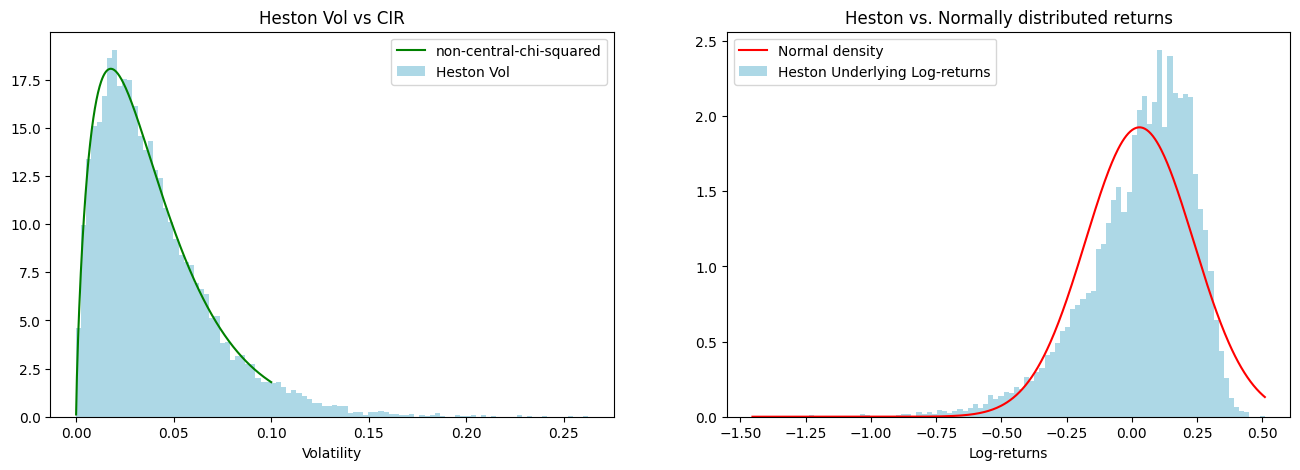

In [24]:
# Obtaining degrees of freedom (do not worry a lot about this now)
c = 2 * kappa_v / ((1 - np.exp(-kappa_v * T)) * sigma_v**2)
df = 4 * kappa_v * theta_v / sigma_v**2
nc = 2 * c * v0 * np.exp(-kappa_v * T)


# Calculating returns and lengths of axis
log_R = np.log(S[-1, :] / S0)
x = np.linspace(log_R.min(), log_R.max(), 500)
y = np.linspace(0.00001, 0.1, 500)


# Plotting the different distributions
fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

# Heston stochastic vol follows a CIR/Vasicek process
ax1.plot(
    y,
    ss.ncx2.pdf(y, df, nc, scale=1 / (2 * c)),
    color="green",
    label="non-central-chi-squared",
)
ax1.hist(V[-1, :], density=True, bins=100, facecolor="LightBlue", label="Heston Vol")
ax1.legend()
ax1.set_title("Heston Vol vs CIR")
ax1.set_xlabel("Volatility")

# Heston underlying returns do not follow a normal distribution
ax2.plot(
    x,
    ss.norm.pdf(x, log_R.mean(), log_R.std(ddof=0)),
    color="r",
    label="Normal density",
)
ax2.hist(
    log_R,
    density=True,
    bins=100,
    facecolor="LightBlue",
    label="Heston Underlying Log-returns",
)
ax2.legend()
ax2.set_title("Heston vs. Normally distributed returns")
ax2.set_xlabel("Log-returns")

In the previous graphs, you can observe the fit (and no-fit) of the different distributions produced to known distributions assumed in other models.


## **4. Conclusion**

Well done! Now you know a lot more about how to implement the Heston model in Python. Arguably, one thing we have not yet covered explicitly is pricing in the Heston framework. This is exactly what we will do in the next lesson.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.